### How to access fine-tuned models in Hugging Face and make prediction

In [1]:
!pip install transformers Pillow

In [10]:
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.50.0
    Uninstalling transformers-4.50.0:
      Successfully uninstalled transformers-4.50.0


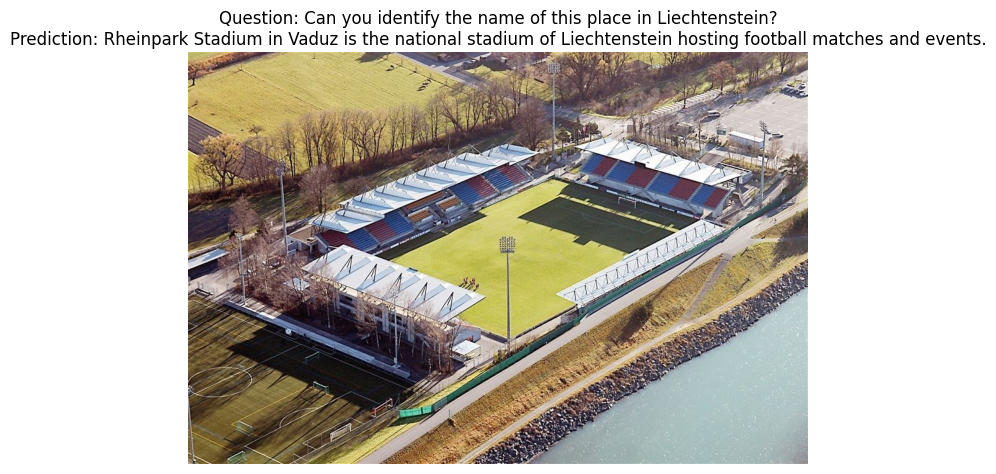

In [14]:
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch
import matplotlib.pyplot as plt

# 1. Load model and processor
model_name = "arad1367/Florence-2-Liechtenstein-TA-OCR-VQA-modified-2000"
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Load custom image
image_path = "/content/6.jpg"
try:
    image = Image.open(image_path).convert("RGB")
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}")
    exit()
except Exception as e:
    print(f"Error loading image: {e}")
    exit()

# 3. Prepare inputs (for VQA)
question = "Can you identify the name of this place in Liechtenstein?"
inputs = processor(images=image, text=question, return_tensors="pt").to(device)

# 4. Perform inference
outputs = model.generate(**inputs, max_length=200)  # Adjust max_length as needed

# 5. Process output (for VQA)
answer = processor.decode(outputs[0], skip_special_tokens=True)

# 6. Display the image and prediction
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title(f"Question: {question}\nPrediction: {answer}")
plt.axis('off')  # Turn off axis numbers and ticks
plt.show()

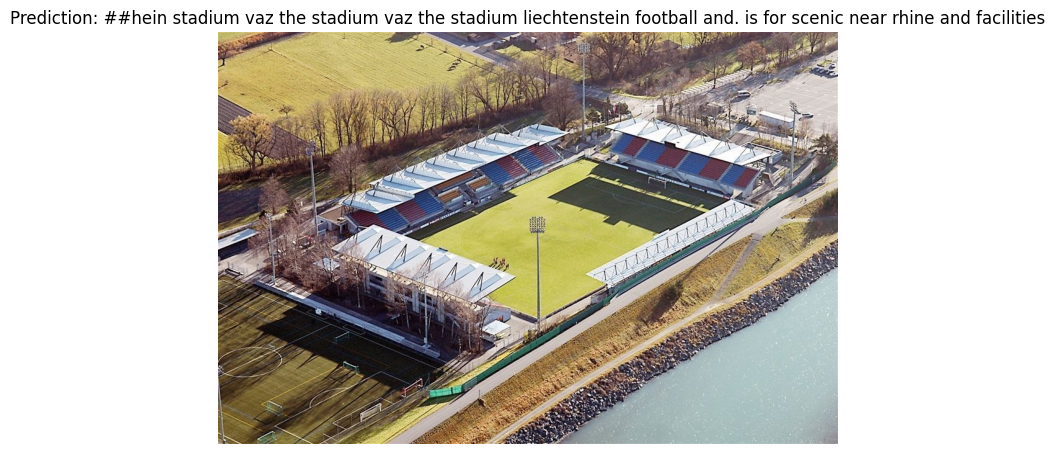

In [16]:
from transformers import AutoProcessor, AutoModelForCausalLM
from PIL import Image
import torch
import matplotlib.pyplot as plt

# 1. Define the fine-tuned model name
model_name = "arad1367/Microsoft-git-base-Liechtenstein-TA-2000"

# 2. Load processor and model
processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 3. Load your custom image
image_path = "/content/6.jpg"
try:
    custom_image = Image.open(image_path).convert("RGB")
except FileNotFoundError:
    print(f"Error: Image not found at {image_path}")
    exit()
except Exception as e:
    print(f"Error loading image: {e}")
    exit()

# 4. Preprocess the image
encoding = processor(images=custom_image, return_tensors="pt").to(device)
pixel_values = encoding['pixel_values']

# 5. Generate the caption
with torch.no_grad():
    outputs = model.generate(pixel_values=pixel_values, max_length=50)

predicted_caption = processor.decode(outputs[0], skip_special_tokens=True)

# 6. Display the image and prediction
plt.figure(figsize=(8, 8))
plt.imshow(custom_image)
plt.title(f"Prediction: {predicted_caption}")
plt.axis('off')
plt.show()